# Project Analysis Demo

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nothing248/notebooks/blob/main/notebooks/project_analysis_demo/analysis.ipynb)

本 Notebook 是一个演示笔记本，展示了如何：
1. **双端环境兼容**（本地与 Google Colab 动态挂载 Drive/自动克隆仓库）
2. **分项目局部依赖加载**（在 Colab 下利用 **uv** 极速自动安装该子目录的 `requirements.txt`）
3. **引用共享的复用模块**（`src/utils.py`）
4. **规范的数据读写**（使用 `utils.get_data_path`）

## 步骤 1：环境初始化与局部依赖安装
当您在 Google Colab 中打开此 Notebook 时，以下单元格将智能检测环境：
* **一劳永逸同步**：挂载 Google Drive，并自动检查 Drive 中是否有此项目。若没有，则**自动克隆至您的 Google Drive 永久存储**，以后无需每次重新克隆，且修改直接在云端持久保存。
* **免登录运行**：若不挂载 Drive，则自动克隆到 Colab 虚拟机临时目录，保证代码和数据可直接导入运行。

In [3]:
import sys
import os

# 1. 检测是否处于 Colab 环境
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    GITHUB_USER = "nothing248"
    REPO_NAME = "notebooks"

    COLAB_LOCAL_PATH = f"/content/{REPO_NAME}"
    DRIVE_BASE_PATH = "/content/drive/MyDrive"
    DRIVE_PATH = f"{DRIVE_BASE_PATH}/{REPO_NAME}"

    # 2. 尝试挂载 Google Drive
    has_drive = False
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        has_drive = os.path.exists(DRIVE_BASE_PATH)
    except Exception as e:
        print("提示: 未挂载 Google Drive，将使用 Colab 临时运行环境。")

    # 3. 决定克隆与运行路径
    if has_drive:
        REPO_PATH = DRIVE_PATH
        # 如果 Google Drive 中不存在该仓库，则自动克隆到 Drive 中永久保留
        if not os.path.exists(REPO_PATH):
            print(f"Google Drive 中未检测到仓库。正在自动克隆到您的 Google Drive...")
            os.chdir(DRIVE_BASE_PATH)
            !git clone https://github.com/{GITHUB_USER}/{REPO_NAME}.git
        else:
            print(f"检测到 Google Drive 中已存在仓库，直接使用: {REPO_PATH}")
    else:
        # 如果未授权 Drive，则退回到 Colab 本地临时虚拟机路径克隆
        REPO_PATH = COLAB_LOCAL_PATH
        if not os.path.exists(REPO_PATH):
            print("正在自动将 GitHub 仓库克隆到 Colab 临时运行环境...")
            !git clone https://github.com/{GITHUB_USER}/{REPO_NAME}.git {REPO_PATH}
        else:
            print(f"Colab 临时运行环境中已存在仓库: {REPO_PATH}")

    # 4. 切换工作路径到当前 Notebook 所在的子项目目录
    TARGET_SUBDIR = os.path.join(REPO_PATH, "notebooks", "project_analysis_demo")
    os.chdir(TARGET_SUBDIR)
    print(f"当前工作目录已成功切换至: {os.getcwd()}")

    # 5. 使用 uv 极速安装子项目专属依赖到 Colab 全局系统
    !pip install uv
    !uv pip install --system -r requirements.txt
else:
    print("当前为本地开发环境，无需自动配置。")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive 中未检测到仓库。正在自动克隆到您的 Google Drive...
Cloning into 'notebooks'...
remote: Enumerating objects: 32, done.
remote: Counting objects: 100% (32/32), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 32 (delta 9), reused 32 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (32/32), 12.70 KiB | 1.59 MiB/s, done.
Resolving deltas: 100% (9/9), done.
当前工作目录已成功切换至: /content/drive/MyDrive/notebooks/notebooks/project_analysis_demo
Using Python 3.12.13 environment at: /usr
Checked 3 packages in 95ms


## 步骤 2：添加项目根目录至系统路径 (sys.path)
因为我们的通用工具模块定义在仓库根目录下的 `src/` 中，为了能直接在 Notebook 里 `import src.utils`，我们需要确保根目录已加入到 `sys.path` 中。

In [5]:
# 寻找项目根目录并加入 sys.path
current_dir = os.path.abspath(os.getcwd())
root_dir = current_dir
for _ in range(5):
    # 向上寻找含有 .git 或 requirements.txt 的根目录
    if os.path.exists(os.path.join(root_dir, '.git')):
        break
    root_dir = os.path.dirname(root_dir)

if root_dir not in sys.path:
    sys.path.append(root_dir)
    print(f"项目根目录已添加至系统路径: {root_dir}")

# 现在我们可以直接引用全局 src 中的工具了！
from src.utils import get_data_path, setup_colab
print("成功导入 src.utils!")

项目根目录已添加至系统路径: /content/drive/MyDrive/notebooks
成功导入 src.utils!


## 步骤 3：数据读取与分析
我们将展示如何通过 `get_data_path()` 读写数据。大文件由 Google Drive 存储，小文件由 Git 追踪，在代码里都用一致的函数处理路径。

In [6]:
import pandas as pd
import numpy as np

# 1. 获取（或自动创建）数据路径下的文件路径
csv_filepath = get_data_path("demo_dataset.csv")
print(f"数据文件存放路径: {csv_filepath}")

# 2. 如果文件不存在，我们生成一份模拟数据存入此路径
if not os.path.exists(csv_filepath):
    df_mock = pd.DataFrame({
        'Date': pd.date_range(start='2026-01-01', periods=100),
        'Category': np.random.choice(['A', 'B', 'C'], size=100),
        'Value': np.random.randn(100).cumsum()
    })
    df_mock.to_csv(csv_filepath, index=False)
    print("未检测到历史数据，已在数据目录下生成模拟数据 'demo_dataset.csv'。")

# 3. 使用 Pandas 加载数据
df = pd.read_csv(csv_filepath)
print(f"成功读取数据！样本数据前 5 行：")
df.head()

数据文件存放路径: /content/drive/MyDrive/notebooks/notebooks/project_analysis_demo/data/demo_dataset.csv
未检测到历史数据，已在数据目录下生成模拟数据 'demo_dataset.csv'。
成功读取数据！样本数据前 5 行：


,Date,Category,Value
0,2026-01-01,C,0.115970
1,2026-01-02,B,1.184956
2,2026-01-03,C,1.925917
3,2026-01-04,C,3.363418
4,2026-01-05,C,3.732698


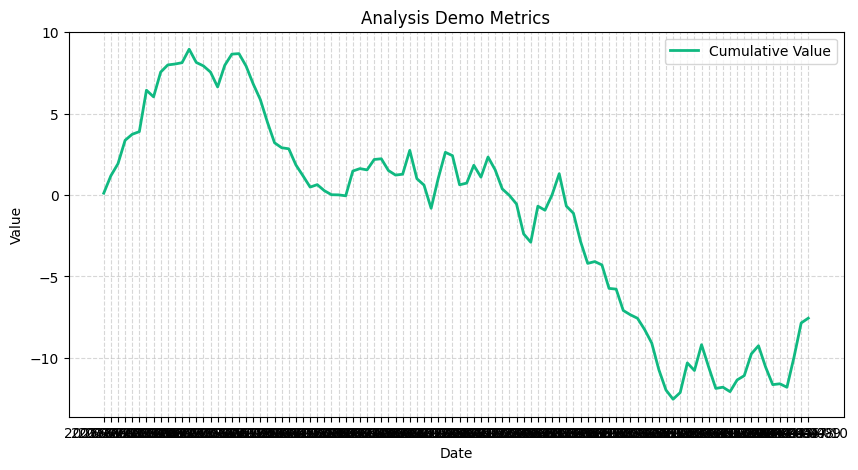

In [7]:
# 4. 简单的数据看板绘制
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(10, 5))
plt.plot(df['Date'], df['Value'], label='Cumulative Value', color='#10b981', linewidth=2)
plt.title('Analysis Demo Metrics')
plt.xlabel('Date')
plt.ylabel('Value')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()